# metabeta — priors and prior sensitivity

This notebook demonstrates how to control and inspect priors in **metabeta**:

1. **Simulate** a Normal dataset from a known prior — so we know the ground truth.
2. **Specify explicit priors** and run a batched prior-sensitivity analysis in a single `sample()` call.
3. **Plot posterior parameters** with prior overlays for each prior variant.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metabeta.models.api import Api

mb = Api.from_pretrained('normal')


## 1. Simulate a Normal dataset

Rather than loading a fixed dataset, we generate data from a known prior. This allows us to check
how well the posterior recovers the true parameters and how prior choice affects inference.

We define the prior hyperparameters explicitly — the same values are later reused as the
`generative` prior in the sensitivity analysis, so the two are guaranteed to match.

The model has **4 fixed effects** (intercept + 3 predictors) and **2 correlated random effects**
(random intercept + random slope on X1).

In [2]:
from metabeta.simulation import Prior, Scammer
from metabeta.simulation.simulator import Simulator

seed = 2
rng = np.random.default_rng(seed)

d = 4      # fixed effects: intercept + X1 + X2 + X3
q = 2      # random effects: random intercept + random X1 slope
m = 15     # number of groups
formula = 'y ~ X1 + X2 + X3 + (1 + X1 | group)'

# Explicit prior hyperparameters — these same values are reused as the
# 'generative' prior in the sensitivity analysis below.
hparams = {
    'likelihood_family': np.array(0),        # Normal (identity link)
    'nu_ffx':            np.zeros(d),         # zero-centered (standardized scale)
    'tau_ffx':           np.array([1.0, 0.8, 0.8, 0.8]),  # per-term scale
    'tau_rfx':           np.array([0.6, 0.6]),             # per-rfx SD scale
    'eta_rfx':           np.array(1.5),       # LKJ concentration
    'family_ffx':        np.array(0),         # Normal
    'family_sigma_rfx':  np.array(0),         # HalfNormal
    'tau_eps':           np.array(1.0),       # residual SD scale
    'family_sigma_eps':  np.array(0),         # HalfNormal
}

prior = Prior(rng, hparams)
scammer = Scammer(rng)
ns = rng.integers(8, 15, size=m)
sim = Simulator(rng, prior, scammer, ns)
ds = sim.sample()

# build DataFrame (drop intercept column X[:, 0] == 1)
df = pd.DataFrame(ds['X'][:, 1:4], columns=['X1', 'X2', 'X3'])
df['y'] = ds['y']
df['group'] = ds['groups']

print(f'Dataset: n={len(df)} observations, m={df["group"].nunique()} groups')
print()
print('True parameters:')
print(f'  fixed effects  (intercept, X1, X2, X3):  {np.round(ds["ffx"], 3)}')
print(f'  sigmas:                                  {np.round(ds["sigma_rfx"], 3)}')
print(f'  sigma_eps:                               {float(ds["sigma_eps"]):.3f}')
print(f'  corr(intercept, X1):                     {ds["corr_rfx"][1, 0]:.3f}')

Dataset: n=167 observations, m=15 groups

True parameters:
  fixed effects  (intercept, X1, X2, X3):  [-0.798  0.367 -0.08   0.44 ]
  sigmas:                                  [0.367 0.077]
  sigma_eps:                               0.899
  corr(intercept, X1):                     -0.418


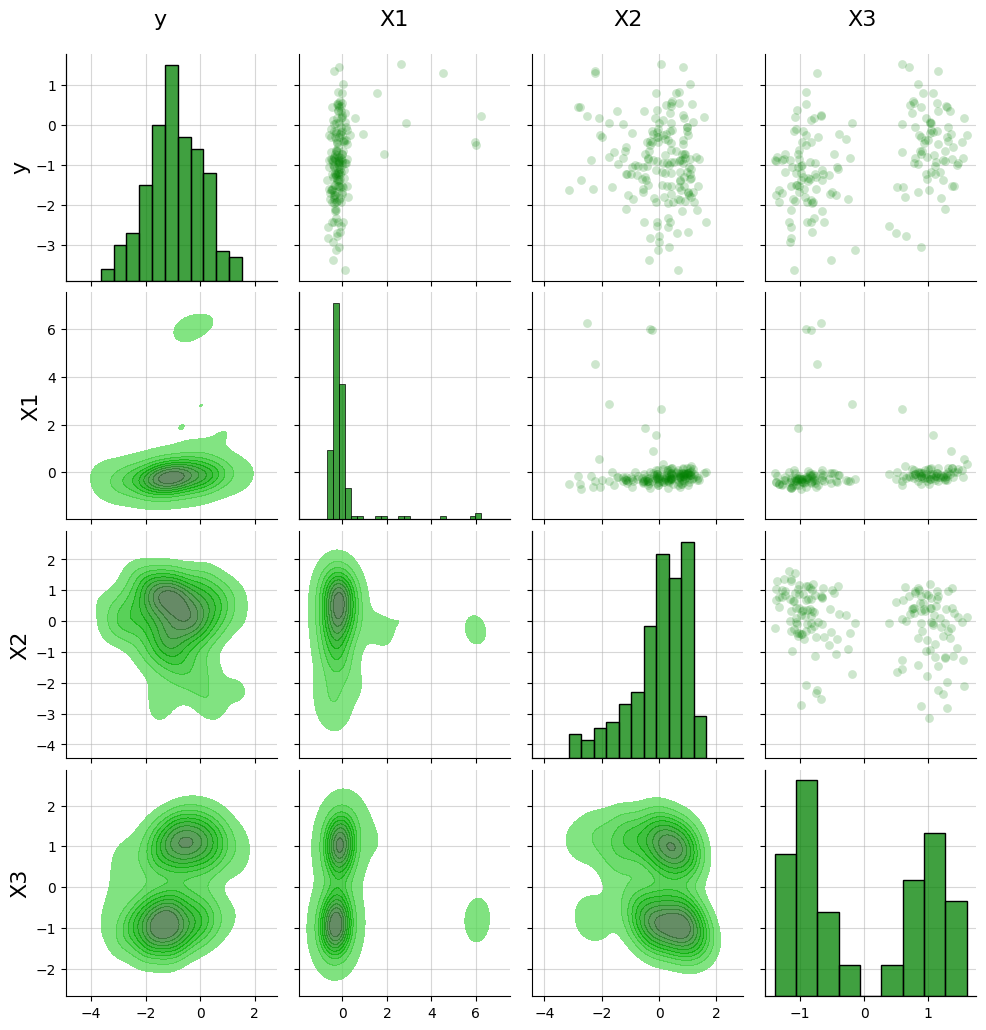

In [3]:
from metabeta.plotting import plotDataset

g = plotDataset(df[['y', 'X1', 'X2', 'X3']])
plt.show()

## 2. Prior sensitivity analysis

We compare three prior specifications in a **single `sample()` call** by passing a named
dictionary.  metabeta stacks them into a batch and runs all three in one forward pass.

| Variant | Description |
|---|---|
| `default` | Model's learned default — weakly informative, bambi-style |
| `generative` | The true generative prior (same `tau` used to simulate the data) |
| `conservative` | Very tight prior that shrinks all effects toward zero |

**Default priors.** When no prior is specified, metabeta applies scales it learned during
training to approximate bambi's weakly informative defaults: for a Normal GLMM on
standardised predictors these are Intercept ~ N(0, 1.5), slopes ~ N(0, 1),
σ_rfx ~ HN(2.5), σ_ε ~ HT(1), and Corr ~ LKJ(1).  They are broad enough that the
likelihood dominates in most practical settings.

Priors use the **term-based schema**:
- `fixed` maps each formula term to `{"tau": value}` — and optionally `{"nu": value}` to
  shift the prior mean away from zero (useful when you have domain knowledge about effect
  direction or magnitude)
- `random_sd` maps each random-effect SD term to a `{"tau": value}` spec
- `sigma_eps` takes `{"tau": value}` for the residual SD (Normal models only)
- `corr_rfx` takes `{"eta": value}` for the LKJ concentration

In [4]:
generative = {
    'fixed': {
        'Intercept': {'tau': float(hparams['tau_ffx'][0]), 'nu': 0.0},
        'X1':        {'tau': float(hparams['tau_ffx'][1]), 'nu': 0.0},
        'X2':        {'tau': float(hparams['tau_ffx'][2]), 'nu': 0.0},
        'X3':        {'tau': float(hparams['tau_ffx'][3]), 'nu': 0.0},
    },
    'random_sd': {
        'Intercept': {'tau': float(hparams['tau_rfx'][0])},
        'X1':        {'tau': float(hparams['tau_rfx'][1])},
    },
    'sigma_eps': {'tau': float(hparams['tau_eps'])},
    'corr_rfx': {'eta': float(hparams['eta_rfx'])},
}

conservative = {
    'fixed': {
        'Intercept': {'tau': 0.5},
        'X1':        {'tau': 0.3},
        'X2':        {'tau': 0.3},
        'X3':        {'tau': 0.3},
    },
    'random_sd': {
        'Intercept': {'tau': 0.3},
        'X1':        {'tau': 0.3},
    },
    'corr_rfx': {'eta': 2.0},
}

priors = {'default': None, 'generative': generative, 'conservative': conservative}

In [5]:
result = mb.sample(
    df,
    formula=formula,
    priors=priors,
    n_samples=1000,
    diagnostics=True,
)

## 3. Posterior summaries

In [6]:
for i, name in enumerate(priors):
    print(f'\n{"="*60}')
    print(f'Prior: {name}')
    print('='*60)
    print(mb.posteriorSummary(result, batch_index=i))


Prior: default
Formula:  y ~ X1 + X2 + X3 + (1 + X1 | group)
n = 167   m = 15
Scale:    standardized covariates
Priors:
  Intercept ~ N(0, 2.5)
  x1 ~ N(0, 2.5)
  x2 ~ N(0, 2.5)
  x3 ~ N(0, 2.5)
  σ_Intercept ~ HN(2.5)
  σ_x1 ~ HN(2.5)
  Corr ~ LKJ(1)
  σ_Residual ~ HT₅(1)

Fixed Effects:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |   P(>0) |   Contr. |
|-----------|--------|-------|--------|---------|---------|---------|----------|
| Intercept | -0.006 | 0.114 | -0.232 |  -0.000 |   0.223 |   0.499 |    0.998 |
| x1        |  0.303 | 0.100 |  0.103 |   0.307 |   0.496 |   0.996 |    0.998 |
| x2        |  0.003 | 0.077 | -0.154 |   0.004 |   0.152 |   0.520 |    0.999 |
| x3        |  0.341 | 0.087 |  0.164 |   0.343 |   0.517 |   0.998 |    0.999 |

Standard Deviations:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |
|-----------|--------|-------|--------|---------|---------|
| Intercept |  0.265 | 0.134 |  0.017 |   0.260 |   0.554 |
| x1        |  0.141 

## 4. Posterior parameter plots with prior overlays

The pair grids show:
- **Green**: marginal posterior KDE / 2D contours
- **Blue**: analytical prior PDF
- **Purple dashed**: ground-truth parameter values

The bottom-right column shows the correlation parameter ρ between the random intercept and
random X1 slope — included automatically when `q ≥ 2` and the model used a LKJ prior.

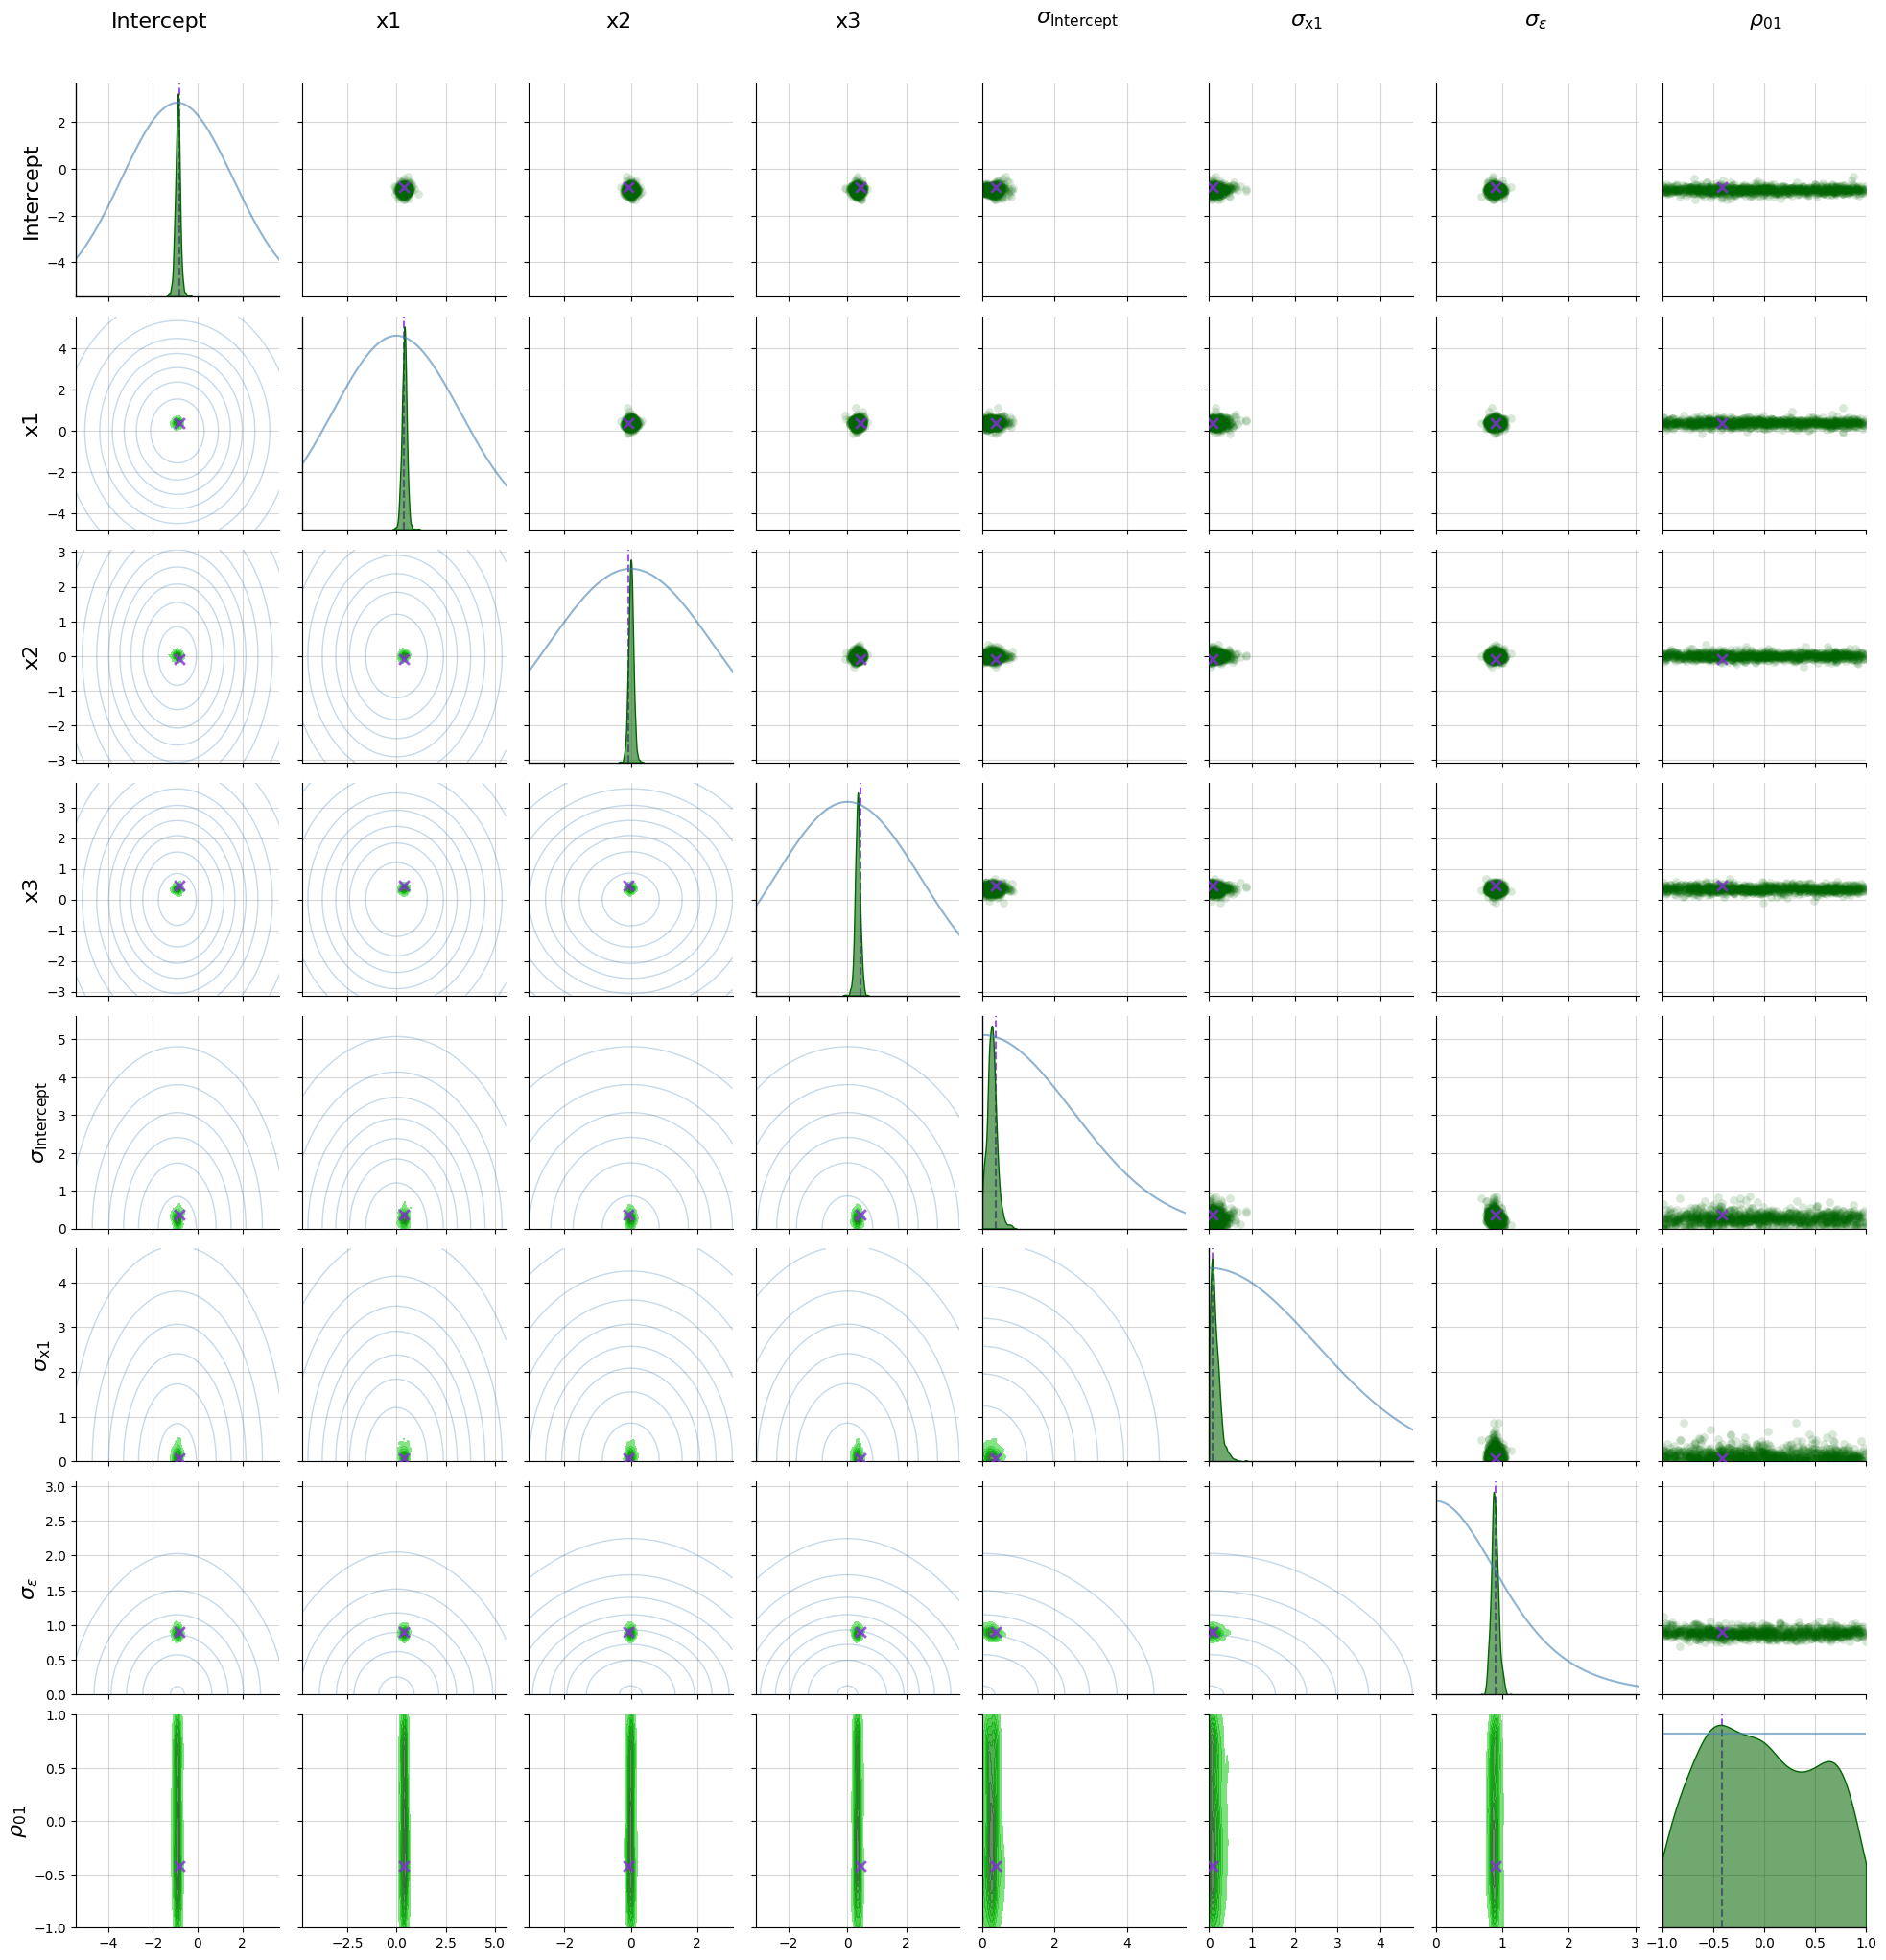

In [7]:
truth = np.concatenate([ds['ffx'], ds['sigma_rfx'], [float(ds['sigma_eps'])], [ds['corr_rfx'][1, 0]]])

g = mb.plotParameters(result, index=0, with_prior=True, truth=truth)  # default
plt.show()

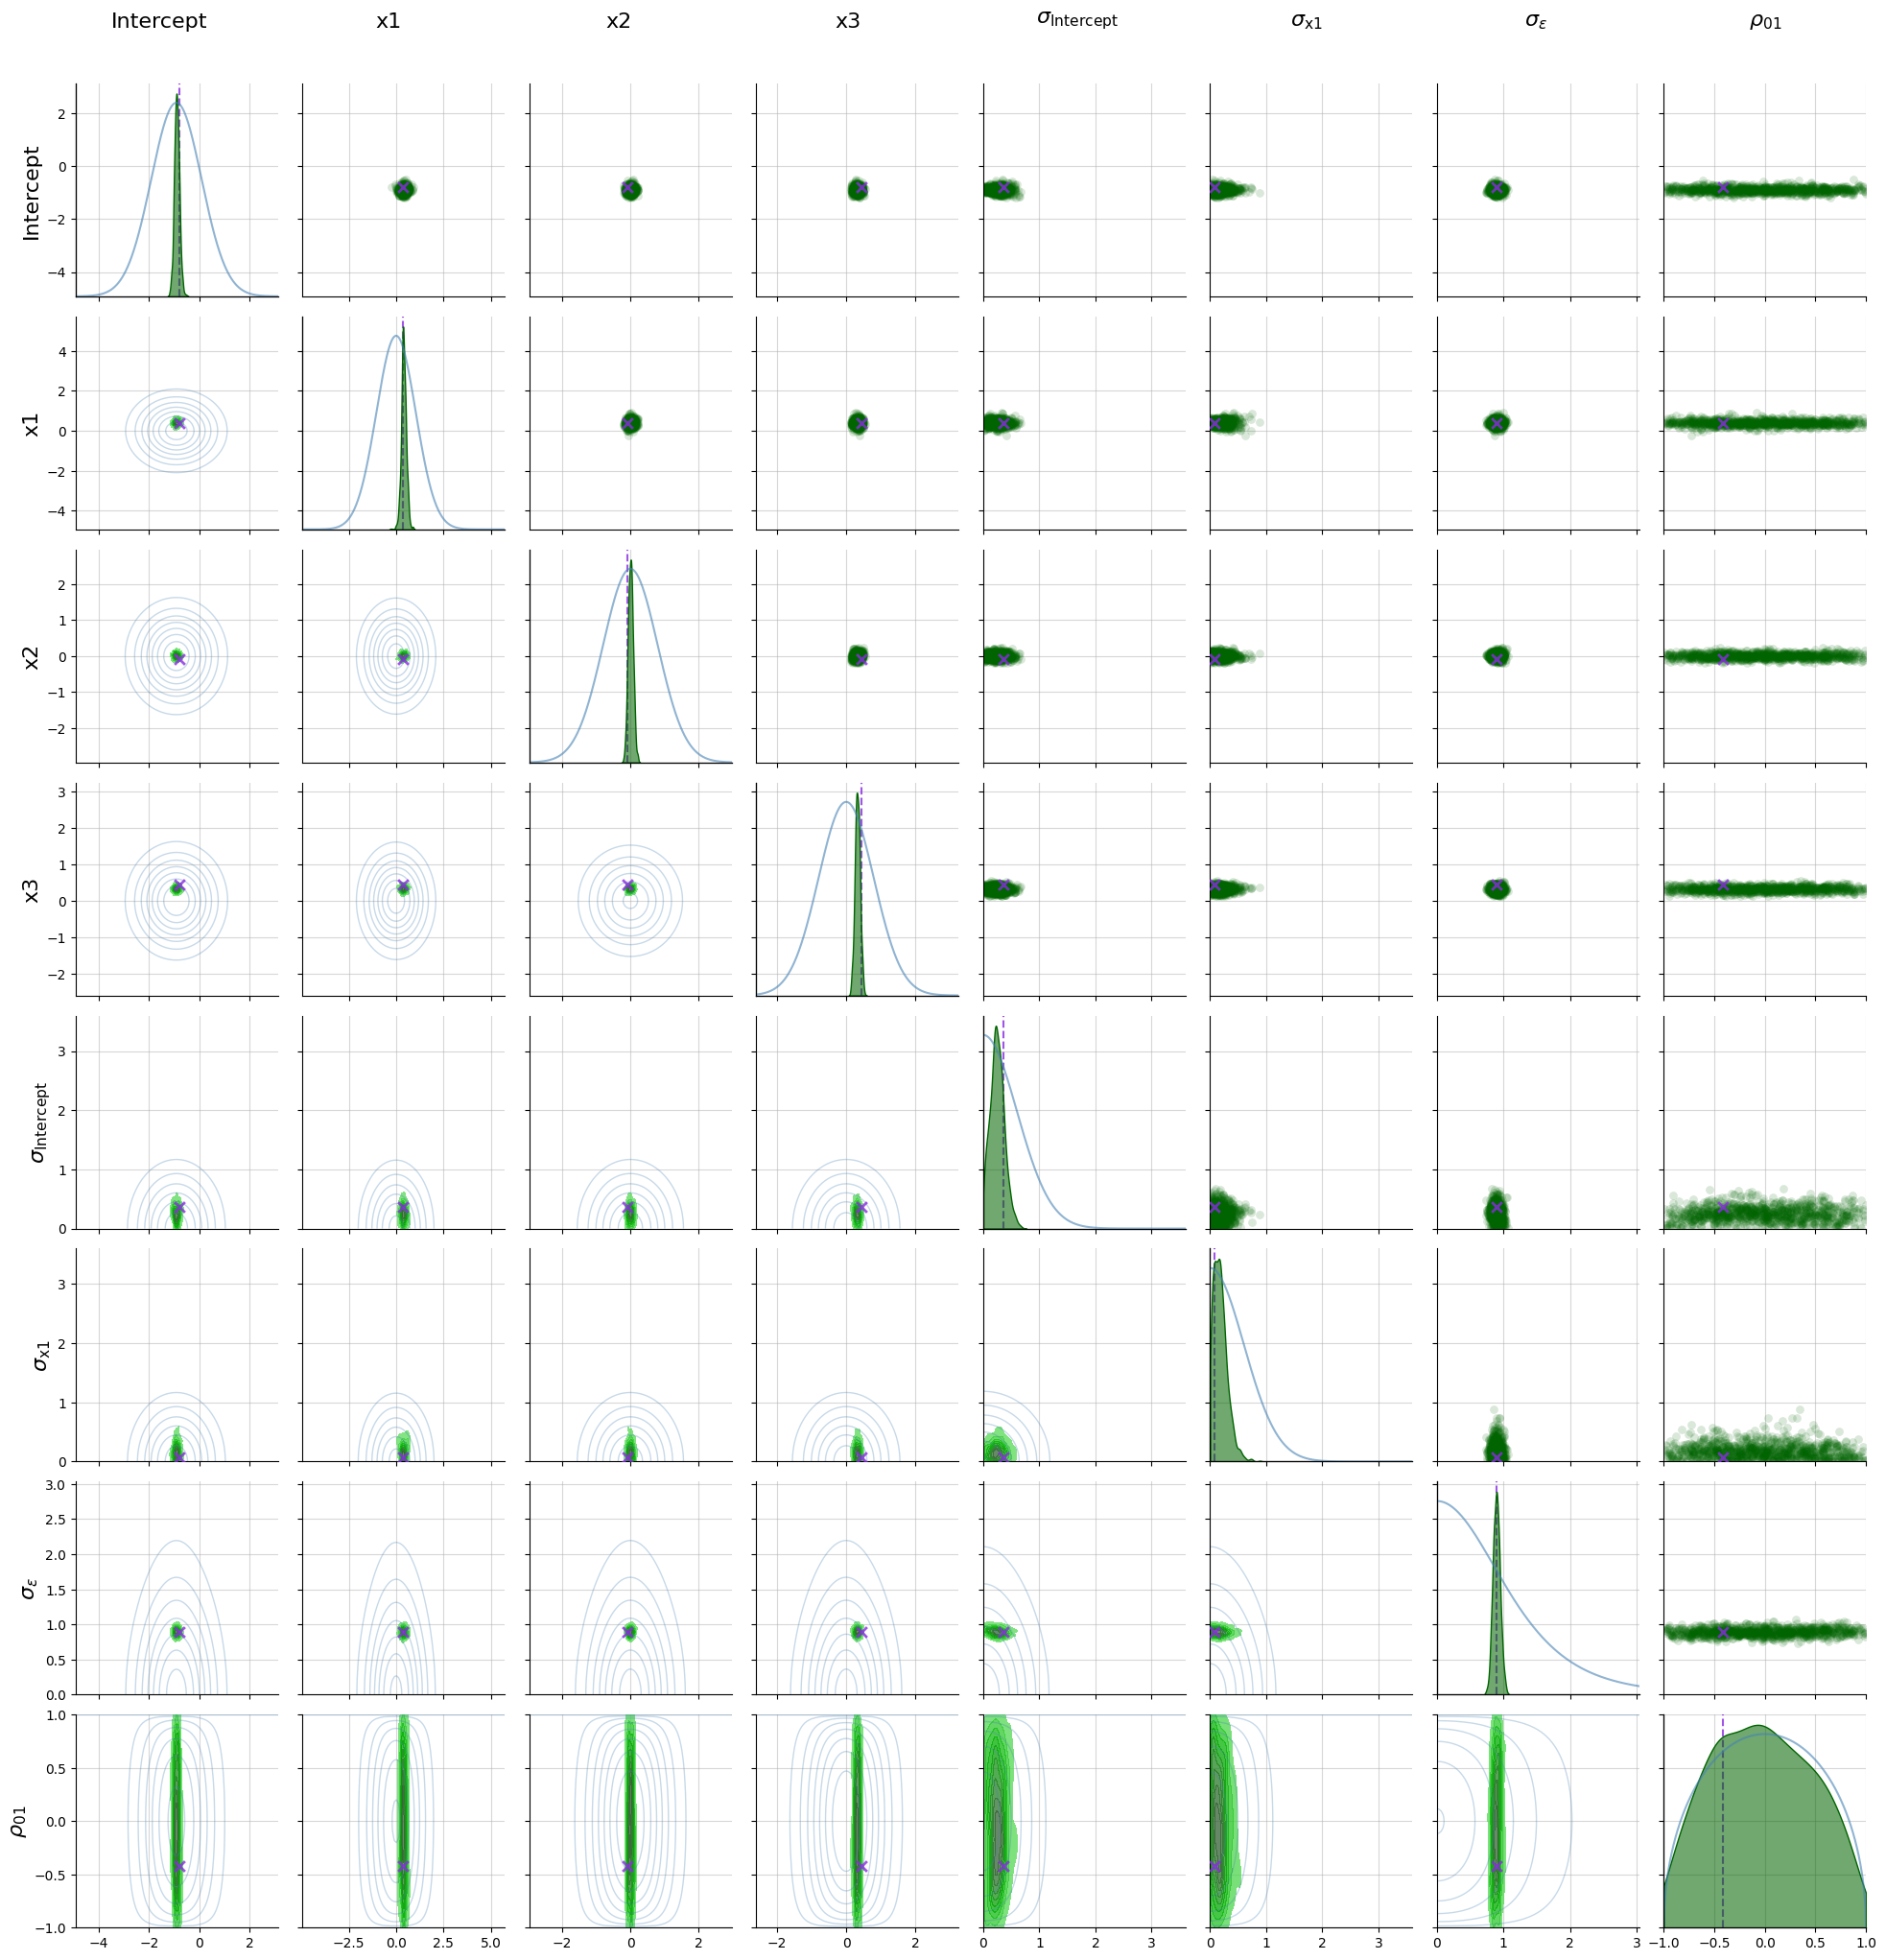

In [8]:
g = mb.plotParameters(result, index=1, with_prior=True, truth=truth)  # generative
plt.show()

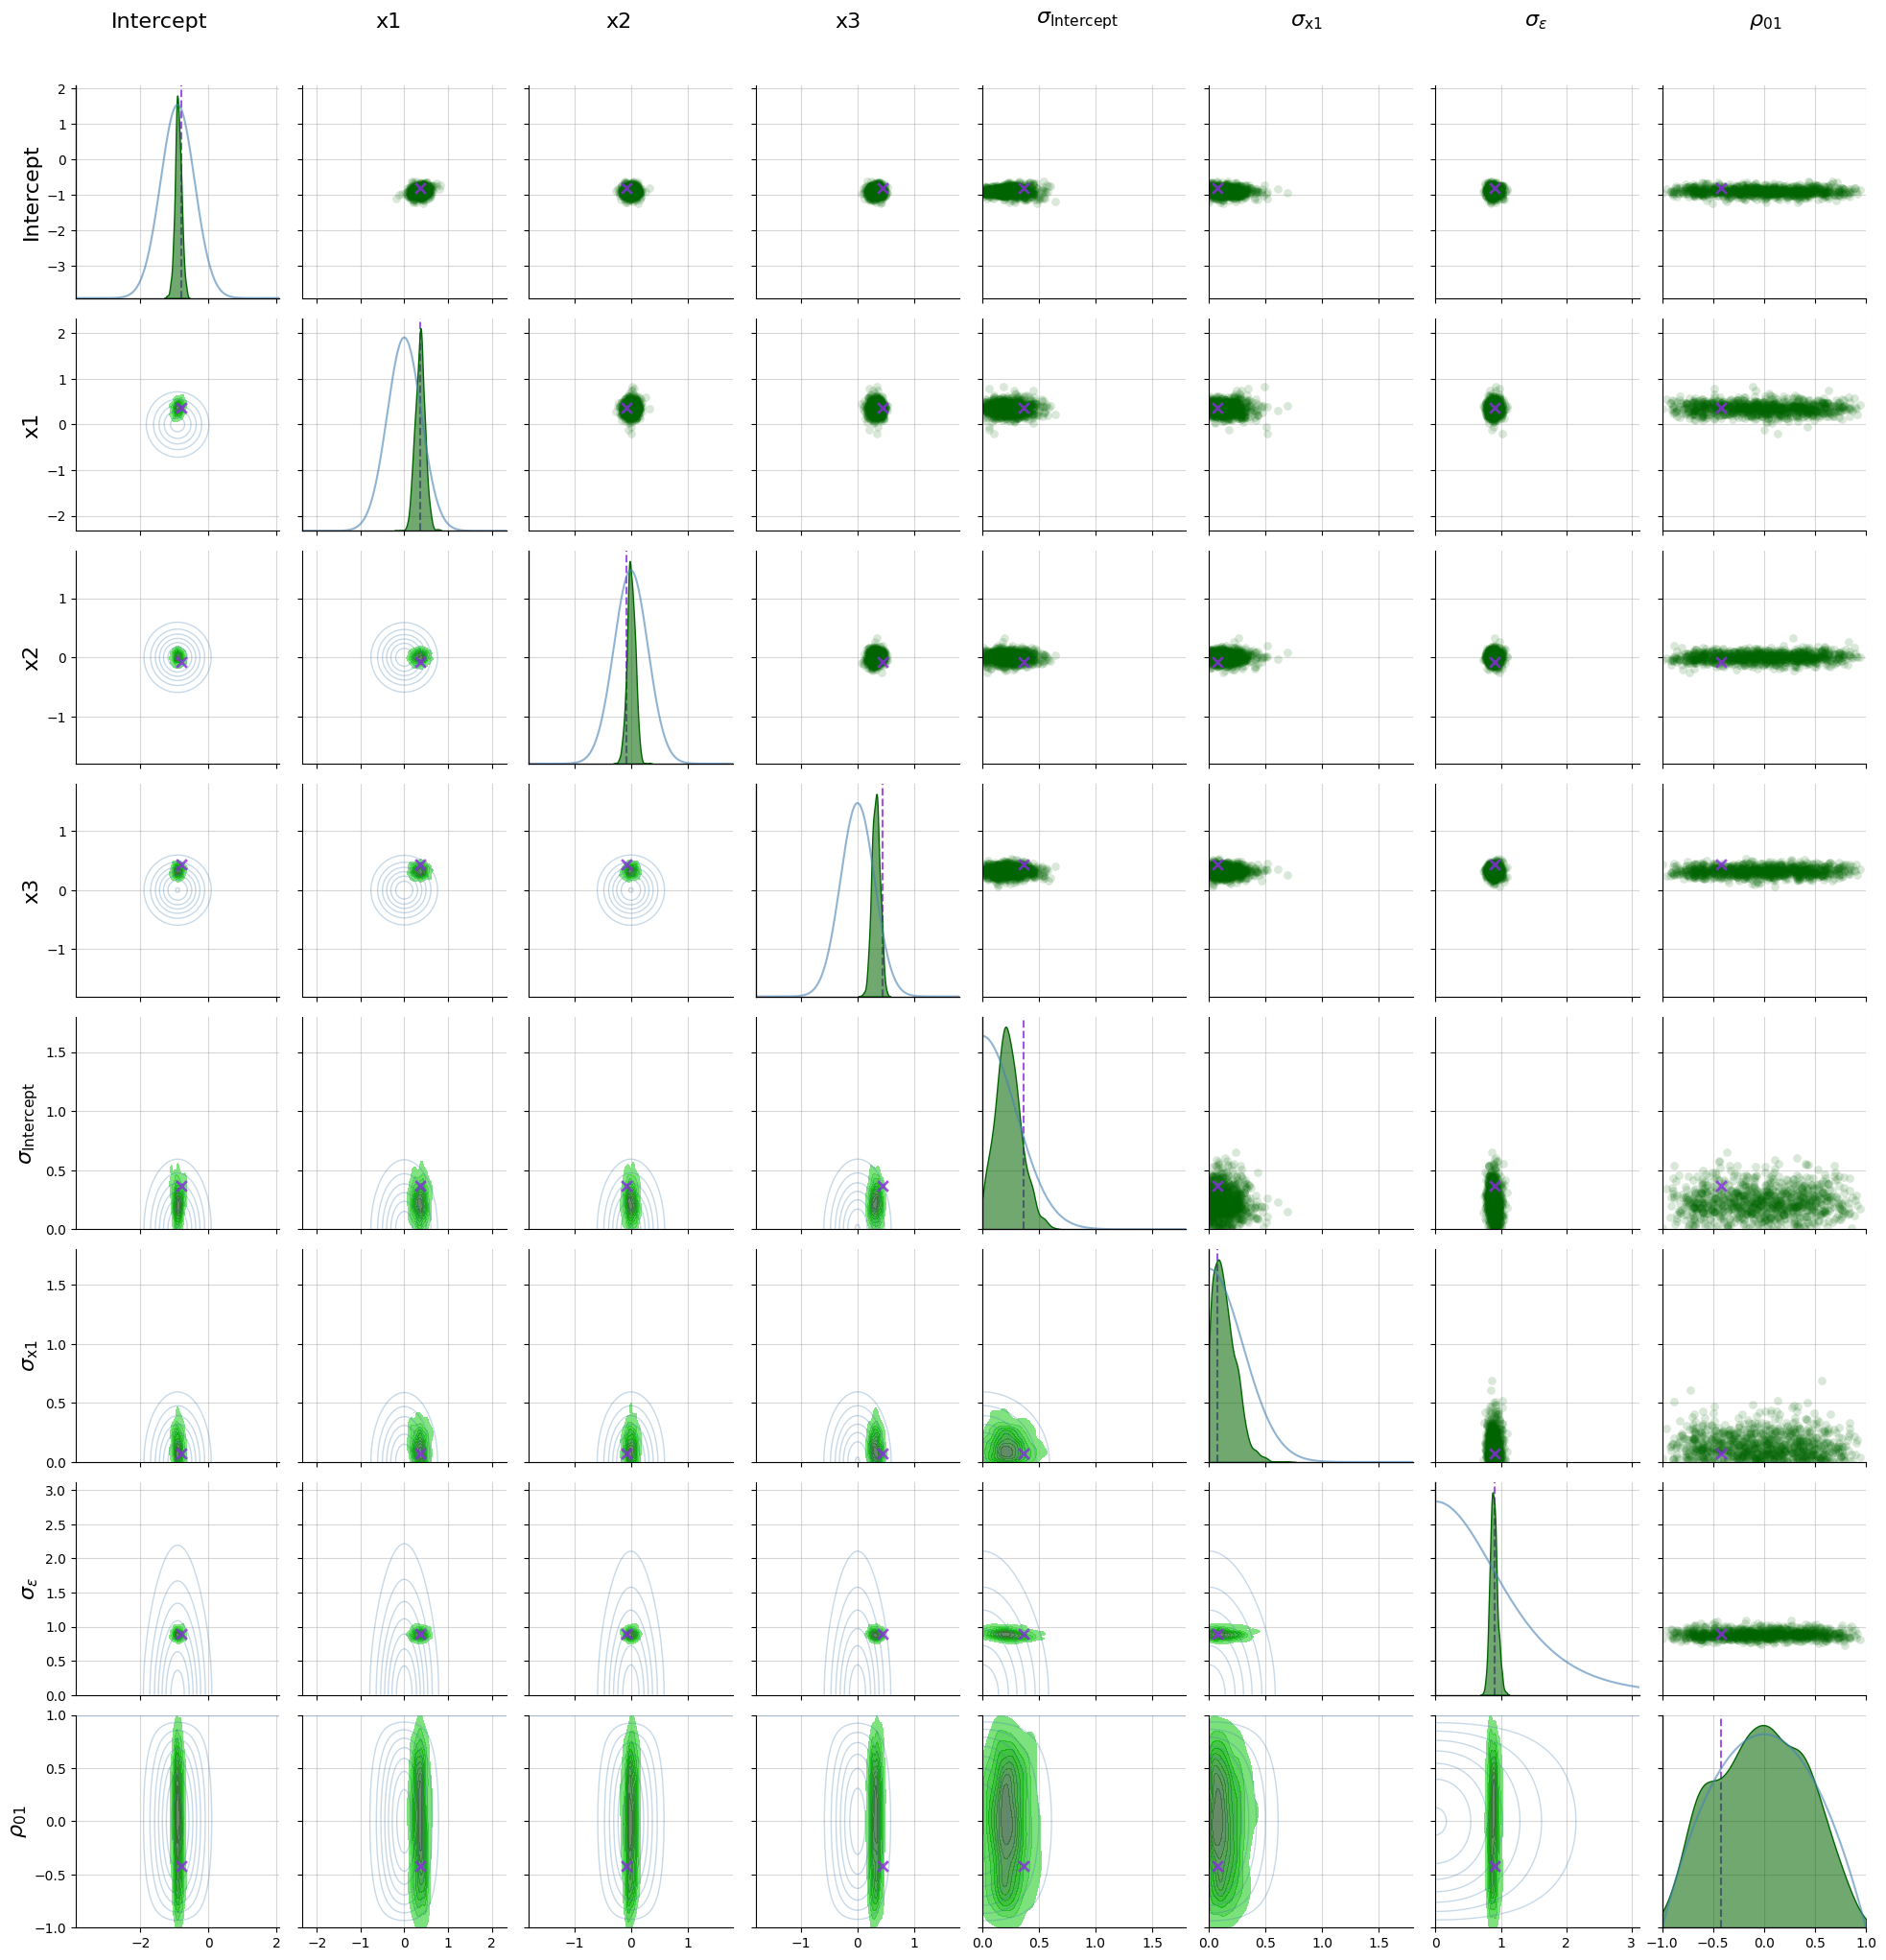

In [9]:
g = mb.plotParameters(result, index=2, with_prior=True, truth=truth)  # skeptical
plt.show()

### Summary

We estimated three GLMMs on the same dataset and formula but different priors — all in a
single batched forward pass.

Predictive fit is nearly identical across variants (R² ≈ 0.77, LOO-NLL 0.877–0.886), so
the prior choice matters little for prediction here.  The differences show up in the
parameter estimates: the **conservative** prior shrinks the fixed effects and random-effect
SDs noticeably toward zero — most visibly on X1 (true β ≈ −0.42, mean −0.40 vs −0.57
for default) and σ_Intercept (0.66 vs 0.83).  The **generative** prior matches the data-
generating process and yields the best LOO-NLL (0.877), with tighter posteriors than the
default.

## 5. Prior families

By default metabeta uses **Normal** priors for fixed effects and **HalfNormal** for random-effect SDs.  Two alternatives are available:

| Setting | `family` key | Shape |
|---|---|---|
| Fixed effects | `"normal"` (default) | symmetric, light tails |
| | `"student"` | symmetric, heavier tails — more robust to outlying effects |
| σ_rfx / σ_ε | `"halfnormal"` (default) | strict shrinkage toward zero |
| | `"halfstudent"` | heavier upper tail — allows larger SDs |
| | `"exponential"` | monotone decay — strong shrinkage, soft floor |

`family` is a top-level key on the `fixed` and `random_sd` blocks (it applies to all terms in that block).


In [ ]:
robust = {
    'fixed': {
        'family':    'student',         # Student-t — heavier tails
        'Intercept': {'tau': 1.5},
        'X1':        {'tau': 0.8},
        'X2':        {'tau': 0.8},
        'X3':        {'tau': 0.8},
    },
    'random_sd': {
        'family':    'exponential',     # Exponential — monotone shrinkage
        'Intercept': {'tau': 0.6},
        'X1':        {'tau': 0.6},
    },
    'sigma_eps': {'tau': 1.0},
    'corr_rfx':  {'eta': 1.5},
}

result_robust = mb.sample(df, formula=formula, priors=robust, n_samples=1000)
print(mb.posteriorSummary(result_robust))
